In [1]:
##1 The structure examination of data to extract patterns and insights supporting informed decision making

   student_id           name  marks  attendance_percentage
0           1   Aarav Sharma     78                     85
1           2     Diya Patel     88                     92
2           3  Krishna Mehta     67                     75
3           4      Isha Shah     91                     95
4           5    Rohan Desai     73                     80
Average Marks: 78.8


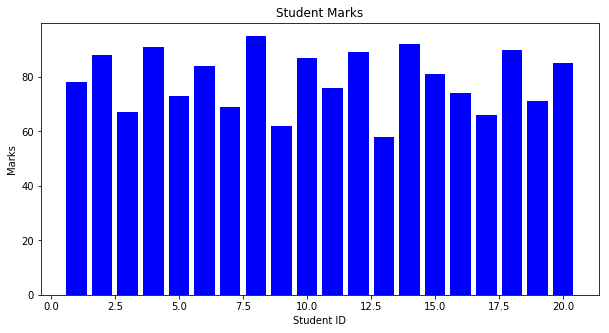

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("stu.csv")

# Show first rows
print(df.head())

# Basic analysis
average_marks = df['marks'].mean()
print("Average Marks:", average_marks)

# Bar plot (Student ID vs Marks)
plt.figure(figsize=(10,5))
plt.bar(df['student_id'], df['marks'], color='blue')

# Labels and title
plt.title("Student Marks")
plt.xlabel("Student ID")
plt.ylabel("Marks")

plt.show()

In [10]:
##4
df.to_excel("stu.xlsx", index=False)

In [12]:
df.to_json("students.json", orient="records")

In [13]:
import sqlite3

# Create database
conn = sqlite3.connect("students.db")

# Store table
df.to_sql("students", conn, if_exists="replace", index=False)

print("Data saved to SQLite!")

conn.close()

Data saved to SQLite!


In [15]:
df_csv = pd.read_csv("stu.csv")
print(df_csv)

    student_id            name  marks  attendance_percentage
0            1    Aarav Sharma     78                     85
1            2      Diya Patel     88                     92
2            3   Krishna Mehta     67                     75
3            4       Isha Shah     91                     95
4            5     Rohan Desai     73                     80
5            6    Ananya Joshi     84                     89
6            7  Vivaan Trivedi     69                     78
7            8      Meera Iyer     95                     97
8            9      Arjun Nair     62                     70
9           10     Kavya Reddy     87                     90
10          11    Aditya Singh     76                     82
11          12    Sneha Kapoor     89                     93
12          13    Raj Malhotra     58                     65
13          14     Pooja Verma     92                     96
14          15     Karan Gupta     81                     88
15          16  Neha Cho

In [16]:
df_excel = pd.read_excel("stu.xlsx")
print(df_excel)

    student_id            name  marks  attendance_percentage
0            1    Aarav Sharma     78                     85
1            2      Diya Patel     88                     92
2            3   Krishna Mehta     67                     75
3            4       Isha Shah     91                     95
4            5     Rohan Desai     73                     80
5            6    Ananya Joshi     84                     89
6            7  Vivaan Trivedi     69                     78
7            8      Meera Iyer     95                     97
8            9      Arjun Nair     62                     70
9           10     Kavya Reddy     87                     90
10          11    Aditya Singh     76                     82
11          12    Sneha Kapoor     89                     93
12          13    Raj Malhotra     58                     65
13          14     Pooja Verma     92                     96
14          15     Karan Gupta     81                     88
15          16  Neha Cho

In [17]:
df_json = pd.read_json("students.json")
print(df_json)

    attendance_percentage  marks            name  student_id
0                      85     78    Aarav Sharma           1
1                      92     88      Diya Patel           2
2                      75     67   Krishna Mehta           3
3                      95     91       Isha Shah           4
4                      80     73     Rohan Desai           5
5                      89     84    Ananya Joshi           6
6                      78     69  Vivaan Trivedi           7
7                      97     95      Meera Iyer           8
8                      70     62      Arjun Nair           9
9                      90     87     Kavya Reddy          10
10                     82     76    Aditya Singh          11
11                     93     89    Sneha Kapoor          12
12                     65     58    Raj Malhotra          13
13                     96     92     Pooja Verma          14
14                     88     81     Karan Gupta          15
15                     7

In [18]:
conn = sqlite3.connect("students.db")

df_sql = pd.read_sql("SELECT * FROM students", conn)
print(df_sql)

conn.close()

    student_id            name  marks  attendance_percentage
0            1    Aarav Sharma     78                     85
1            2      Diya Patel     88                     92
2            3   Krishna Mehta     67                     75
3            4       Isha Shah     91                     95
4            5     Rohan Desai     73                     80
5            6    Ananya Joshi     84                     89
6            7  Vivaan Trivedi     69                     78
7            8      Meera Iyer     95                     97
8            9      Arjun Nair     62                     70
9           10     Kavya Reddy     87                     90
10          11    Aditya Singh     76                     82
11          12    Sneha Kapoor     89                     93
12          13    Raj Malhotra     58                     65
13          14     Pooja Verma     92                     96
14          15     Karan Gupta     81                     88
15          16  Neha Cho

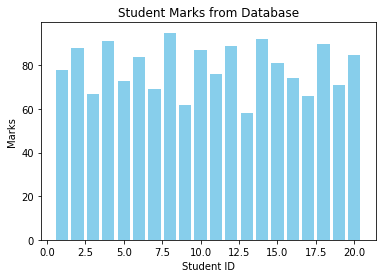

In [20]:
import matplotlib.pyplot as plt

plt.bar(df_sql['student_id'], df_sql['marks'], color='skyblue')

plt.title("Student Marks from Database")
plt.xlabel("Student ID")
plt.ylabel("Marks")

plt.show()

In [21]:
##6

Total records after integration: 4000

Correlation:
                marks  attandance
marks       1.000000   -0.020067
attandance -0.020067    1.000000

Top Students Count: 924


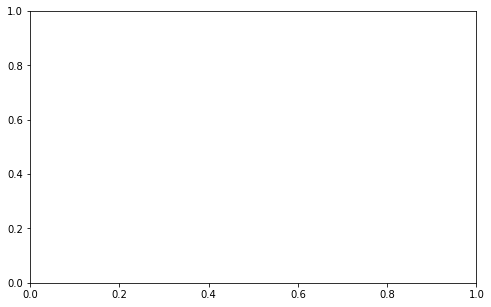

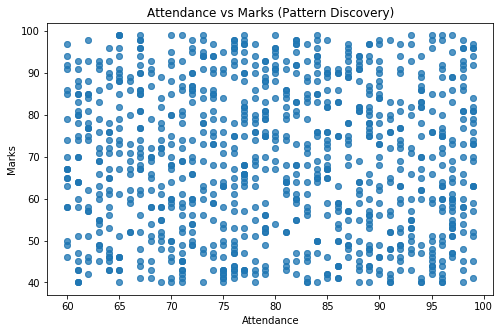

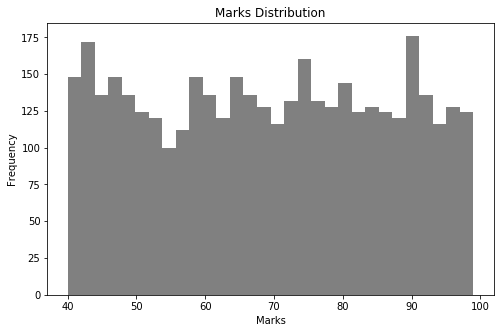

In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)

n = 1000  

data = {
    "studentid": range(1, n+1),
    "marks": np.random.randint(40, 100, n),
    "attandance": np.random.randint(60, 100, n)
}

df = pd.DataFrame(data)


df.to_csv("students.csv", index=False)
df.to_excel("students.xlsx", index=False)
df.to_json("students.json", orient="records")

#sql
conn = sqlite3.connect("students.db")
df.to_sql("students", conn, if_exists="replace", index=False)

df_csv = pd.read_csv("students.csv")
df_excel = pd.read_excel("students.xlsx")
df_json = pd.read_json("students.json")
df_sql = pd.read_sql("SELECT * FROM students", conn)

df_all = pd.concat([df_csv, df_excel, df_json, df_sql])

print("Total records after integration:", len(df_all))

correlation = df_all[['marks', 'attandance']].corr()
print("\nCorrelation:\n", correlation)

high_scores = df_all[df_all['marks'] > 85]
print("\nTop Students Count:", len(high_scores))


plt.figure(figsize=(8,5))
plt.scatter(df_all['attandance'], df_all['marks'], alpha=0.3)

plt.title("Attendance vs Marks (Pattern Discovery)")
plt.xlabel("Attendance")
plt.ylabel("Marks")

plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_all['marks'], bins=30, color='grey')

plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.show()


conn.close()

In [26]:
##9

In [29]:
import pandas as pd
import sqlite3

df_csv = pd.read_csv("stu.csv")
df_excel = pd.read_excel("stu.xlsx")
df_json = pd.read_json("students.json")

conn = sqlite3.connect("students.db")
df_sql = pd.read_sql("SELECT * FROM students", conn)


df_all = pd.concat([df_csv, df_excel, df_json, df_sql], ignore_index=True)

# Remove duplicates
df_all = df_all.drop_duplicates()

print("Integrated Data Shape:", df_all.shape)
print(df_all)
print (df_all.head(10))

conn.close()

Integrated Data Shape: (1020, 6)
      attandance  attendance_percentage  marks            name  student_id  \
0            NaN                   85.0     78    Aarav Sharma         1.0   
1            NaN                   92.0     88      Diya Patel         2.0   
2            NaN                   75.0     67   Krishna Mehta         3.0   
3            NaN                   95.0     91       Isha Shah         4.0   
4            NaN                   80.0     73     Rohan Desai         5.0   
5            NaN                   89.0     84    Ananya Joshi         6.0   
6            NaN                   78.0     69  Vivaan Trivedi         7.0   
7            NaN                   97.0     95      Meera Iyer         8.0   
8            NaN                   70.0     62      Arjun Nair         9.0   
9            NaN                   90.0     87     Kavya Reddy        10.0   
10           NaN                   82.0     76    Aditya Singh        11.0   
11           NaN               